# One-Class SVM for Network Anomaly Detection

## Objective

The objective of this notebook is to evaluate the performance of the One-Class Support Vector Machine (One-Class SVM) for detecting anomalous network traffic in the CICIDS2017 DDoS dataset. Unlike supervised classifiers, One-Class SVM is trained only on normal (BENIGN) traffic and learns the boundary of normal behavior. Any traffic lying outside this boundary is classified as anomalous.

In [1]:
#Importing libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df = pd.read_csv("../data/ddos_clean.csv")

print(df.shape)
df.head()
df["Anomaly"] = (
    df[" Label"] != "BENIGN"
).astype(int)
X = df.drop([" Label", "Anomaly"], axis=1)
y_true = df["Anomaly"]

(223082, 43)


In [3]:
#Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
#Training on only BENIGN data
X_train = X_scaled[y_true == 0]
print("Training samples:", X_train.shape)

Training samples: (95068, 42)


In [5]:
#First OCSVM
ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.05
)
ocsvm.fit(X_train)

,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.05
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1
Name,Type,Value


In [6]:
#Prediction on entire dataset
y_pred_raw = ocsvm.predict(X_scaled)

print("Raw Prediction Distribution:")
print(pd.Series(y_pred_raw).value_counts())

Raw Prediction Distribution:
 1    197306
-1     25776
Name: count, dtype: int64


In [7]:
# Convert predictions
# -1 -> anomaly (1)
#  1 -> normal (0)

y_pred = (y_pred_raw == -1).astype(int)

print("\nConverted Prediction Distribution:")
print(pd.Series(y_pred).value_counts())


Converted Prediction Distribution:
0    197306
1     25776
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       0.46      0.95      0.62     95068
           1       0.82      0.16      0.27    128014

    accuracy                           0.50    223082
   macro avg       0.64      0.56      0.45    223082
weighted avg       0.66      0.50      0.42    223082



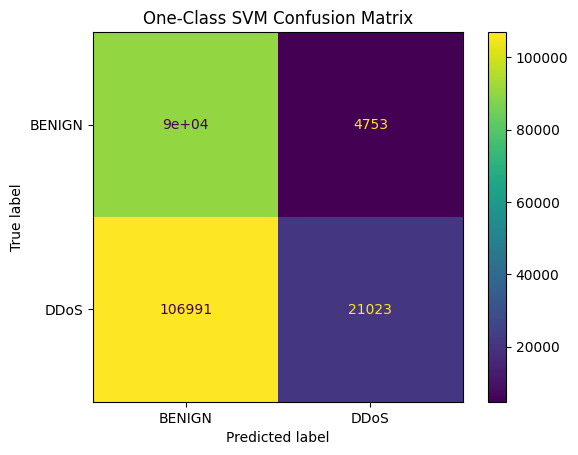

In [8]:
print(classification_report(y_true, y_pred))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["BENIGN", "DDoS"]
)

plt.title("One-Class SVM Confusion Matrix")
plt.show()

## Hyperparameter Tuning: Effect of `nu`

The `nu` parameter in One-Class SVM controls the expected fraction of outliers in the training data and influences the decision boundary. Lower values produce a stricter model that classifies fewer samples as anomalies, whereas higher values produce a more flexible boundary. Multiple values of `nu` are evaluated to determine the configuration that provides the best balance between precision, recall, and F1-score.

In [9]:


def evaluate_ocsvm(nu, X_train, X_test, y_true):
    model = OneClassSVM(
        kernel='rbf',
        gamma='scale',
        nu=nu
    )

    model.fit(X_train)

    y_pred_raw = model.predict(X_test)

    # Convert predictions
    # -1 -> anomaly (1)
    #  1 -> normal (0)
    y_pred = (y_pred_raw == -1).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("=" * 50)
    print(f"nu = {nu}")
    print("=" * 50)
    print(f"Predicted anomalies : {y_pred.sum()}")
    print(f"Actual anomalies    : {y_true.sum()}")

    print(f"\nPrecision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return {
        "nu": nu,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "model": model,
        "y_pred": y_pred
    }

In [10]:
nu_values = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3]

results = []

for nu in nu_values:
    result = evaluate_ocsvm(
        nu,
        X_train,
        X_scaled,
        y_true
    )

    results.append(result)

nu = 0.01
Predicted anomalies : 13641
Actual anomalies    : 128014

Precision : 0.9305
Recall    : 0.0992
F1 Score  : 0.1792
nu = 0.03
Predicted anomalies : 19754
Actual anomalies    : 128014

Precision : 0.8558
Recall    : 0.1321
F1 Score  : 0.2288
nu = 0.05
Predicted anomalies : 25776
Actual anomalies    : 128014

Precision : 0.8156
Recall    : 0.1642
F1 Score  : 0.2734
nu = 0.1
Predicted anomalies : 35119
Actual anomalies    : 128014

Precision : 0.7293
Recall    : 0.2001
F1 Score  : 0.3140
nu = 0.2
Predicted anomalies : 47729
Actual anomalies    : 128014

Precision : 0.6016
Recall    : 0.2243
F1 Score  : 0.3268
nu = 0.3
Predicted anomalies : 68719
Actual anomalies    : 128014

Precision : 0.5850
Recall    : 0.3140
F1 Score  : 0.4087


In [11]:
summary = pd.DataFrame([
    {
        "nu": r["nu"],
        "Precision": round(r["precision"], 4),
        "Recall": round(r["recall"], 4),
        "F1-Score": round(r["f1"], 4)
    }
    for r in results
])

summary

,nu,Precision,Recall,F1-Score
0,0.01,0.9305,0.0992,0.1792
1,0.03,0.8558,0.1321,0.2288
2,0.05,0.8156,0.1642,0.2734
3,0.10,0.7293,0.2001,0.3140
4,0.20,0.6016,0.2243,0.3268
5,0.30,0.5850,0.3140,0.4087


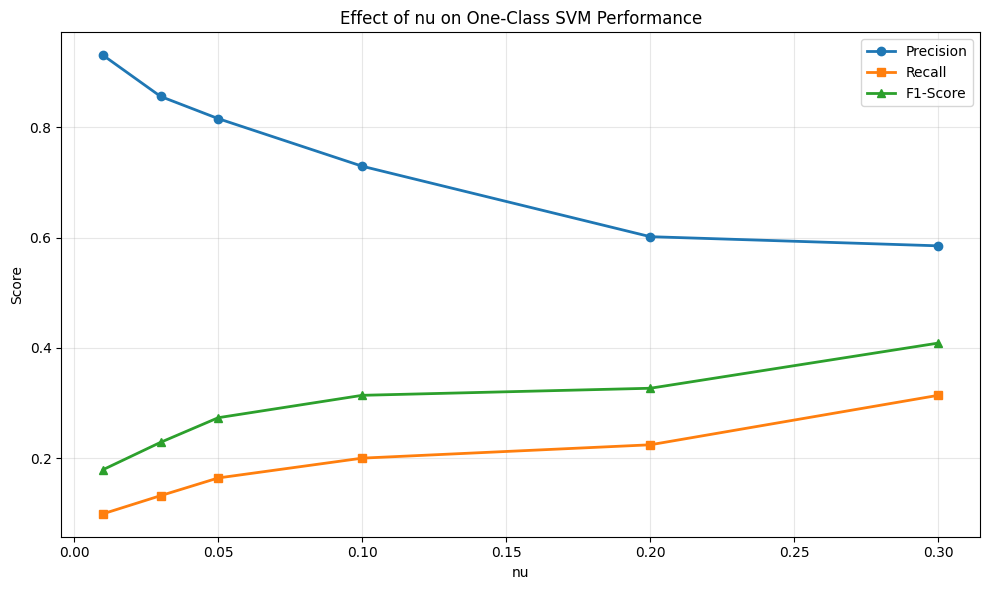

In [16]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(
    summary["nu"],
    summary["Precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

ax.plot(
    summary["nu"],
    summary["Recall"],
    marker="s",
    linewidth=2,
    label="Recall"
)

ax.plot(
    summary["nu"],
    summary["F1-Score"],
    marker="^",
    linewidth=2,
    label="F1-Score"
)

ax.set_xlabel("nu")
ax.set_ylabel("Score")
ax.set_title("Effect of nu on One-Class SVM Performance")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    "../figures/ocsvm_nu_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The effect of the `nu` parameter on One-Class SVM performance was evaluated by varying its value from 0.01 to 0.30 while keeping the RBF kernel and `gamma='scale'` constant.

As the value of `nu` increased, the model classified a larger number of samples as anomalies. This resulted in a gradual decrease in precision but a significant increase in recall. The F1-score improved consistently across all tested values, reaching its highest value of **0.4087** at **ν = 0.30**.

Since the F1-score provides a balanced measure of precision and recall, **ν = 0.30** was selected as the optimal hyperparameter for the final One-Class SVM model.

In [12]:
def evaluate_gamma(gamma, X_train, X_test, y_true):

    model = OneClassSVM(
        kernel='rbf',
        nu=0.30,
        gamma=gamma
    )

    model.fit(X_train)

    y_pred = (model.predict(X_test) == -1).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("="*50)
    print(f"Gamma = {gamma}")
    print("="*50)
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return {
        "gamma": gamma,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "model": model
    }

In [13]:
gamma_values = [
    "scale",
    "auto",
    0.001,
    0.01,
    0.1
]

gamma_results = []

for g in gamma_values:

    result = evaluate_gamma(
        g,
        X_train,
        X_scaled,
        y_true
    )

    gamma_results.append(result)

Gamma = scale
Precision : 0.5850
Recall    : 0.3140
F1 Score  : 0.4087
Gamma = auto
Precision : 0.6123
Recall    : 0.3518
F1 Score  : 0.4469
Gamma = 0.001
Precision : 0.4869
Recall    : 0.2115
F1 Score  : 0.2949
Gamma = 0.01
Precision : 0.5471
Recall    : 0.2692
F1 Score  : 0.3608
Gamma = 0.1
Precision : 0.7796
Recall    : 0.7879
F1 Score  : 0.7837


In [ ]:
gamma_df = pd.DataFrame([
    {
        "Gamma": r["gamma"],
        "Precision": round(r["precision"],4),
        "Recall": round(r["recall"],4),
        "F1-Score": round(r["f1"],4)
    }
    for r in gamma_results
])

print(gamma_df)

   Gamma  Precision  Recall  F1-Score
0  scale     0.5850  0.3140    0.4087
1   auto     0.6123  0.3518    0.4469
2  0.001     0.4869  0.2115    0.2949
3   0.01     0.5471  0.2692    0.3608
4    0.1     0.7796  0.7879    0.7837


### Observation

The effect of the `gamma` parameter was evaluated while keeping the RBF kernel and the optimal value of `ν = 0.30` fixed.

The results indicate that the choice of `gamma` has a significant impact on the performance of the One-Class SVM model. Very small values of `gamma` produced smoother decision boundaries, resulting in lower recall and F1-score. As `gamma` increased, both precision and recall improved considerably.

Among all tested values, **γ = 0.1** achieved the highest performance with a **Precision of 0.7796**, **Recall of 0.7879**, and an **F1-score of 0.7837**.

We shall further check for **γ = 0.2**

In [18]:
gamma_values = [
    0.05,
    0.2
]

for g in gamma_values:

    result = evaluate_gamma(
        g,
        X_train,
        X_scaled,
        y_true
    )

    gamma_results.append(result)


Gamma = 0.05
Precision : 0.7410
Recall    : 0.6375
F1 Score  : 0.6854
Gamma = 0.2
Precision : 0.7975
Recall    : 0.8771
F1 Score  : 0.8354


In [20]:
gamma_df = pd.DataFrame([
    {
        "Gamma": r["gamma"],
        "Precision": round(r["precision"],4),
        "Recall": round(r["recall"],4),
        "F1-Score": round(r["f1"],4)
    }
    for r in gamma_results
])

print(gamma_df)

   Gamma  Precision  Recall  F1-Score
0  scale     0.5850  0.3140    0.4087
1   auto     0.6123  0.3518    0.4469
2  0.001     0.4869  0.2115    0.2949
3   0.01     0.5471  0.2692    0.3608
4    0.1     0.7796  0.7879    0.7837
5   0.05     0.7410  0.6375    0.6854
6    0.2     0.7975  0.8771    0.8354


# Observaton:
 The effect of the gamma parameter was evaluated while fixing ν = 0.30. Increasing gamma significantly improved the model's ability to separate benign and attack traffic. Among the tested values, γ = 0.20 achieved the highest Precision (0.7975), Recall (0.8771), and F1-score (0.8354), making it the optimal parameter for the final One-Class SVM model.

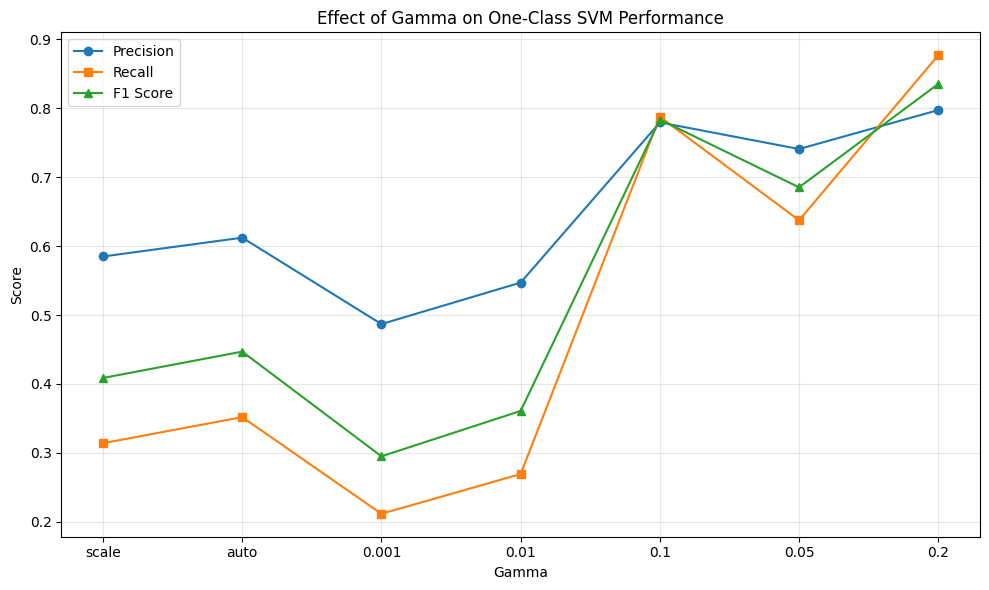

In [21]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(gamma_df["Gamma"].astype(str),
        gamma_df["Precision"],
        marker='o',
        label="Precision")

ax.plot(gamma_df["Gamma"].astype(str),
        gamma_df["Recall"],
        marker='s',
        label="Recall")

ax.plot(gamma_df["Gamma"].astype(str),
        gamma_df["F1-Score"],
        marker='^',
        label="F1 Score")

ax.set_xlabel("Gamma")
ax.set_ylabel("Score")
ax.set_title("Effect of Gamma on One-Class SVM Performance")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/ocsvm_gamma_effect.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
best_ocsvm = OneClassSVM(
    kernel='rbf',
    nu=0.30,
    gamma=0.2
)

best_ocsvm.fit(X_train)
y_pred = (best_ocsvm.predict(X_scaled) == -1).astype(int)

print(classification_report(y_true, y_pred))


cm = confusion_matrix(y_true, y_pred)
print(cm)

              precision    recall  f1-score   support

           0       0.81      0.70      0.75     95068
           1       0.80      0.88      0.84    128014

    accuracy                           0.80    223082
   macro avg       0.80      0.79      0.79    223082
weighted avg       0.80      0.80      0.80    223082

[[ 66548  28520]
 [ 15729 112285]]


### Observation

The final One-Class SVM model was trained using an RBF kernel with the optimized hyperparameters **ν = 0.30** and **γ = 0.20**.

Hyperparameter tuning significantly improved the model's performance compared to the default configuration. The optimized model achieved an overall accuracy of **80%** and an F1-score of **0.84** for the DDoS class.

The confusion matrix indicates that the model successfully detected **112,285** out of **128,014** attack instances while correctly classifying **66,548** benign samples. Although some benign traffic was misclassified as anomalous, the model achieved a high recall (**0.88**) for attack detection, which is desirable in cybersecurity applications where missing malicious traffic is more critical than generating additional alerts.

Overall, the optimized One-Class SVM outperformed both the Z-Score and Isolation Forest approaches, demonstrating that careful hyperparameter tuning substantially improves anomaly detection performance.

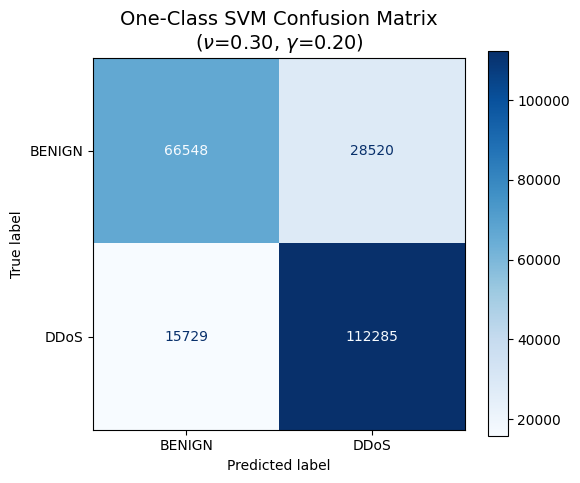

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["BENIGN", "DDoS"],
    cmap="Blues",
    values_format='d',
    ax=ax
)

plt.title("One-Class SVM Confusion Matrix\n($\\nu$=0.30, $\\gamma$=0.20)", fontsize=14)

plt.savefig(
    "../figures/ocsvm_best_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

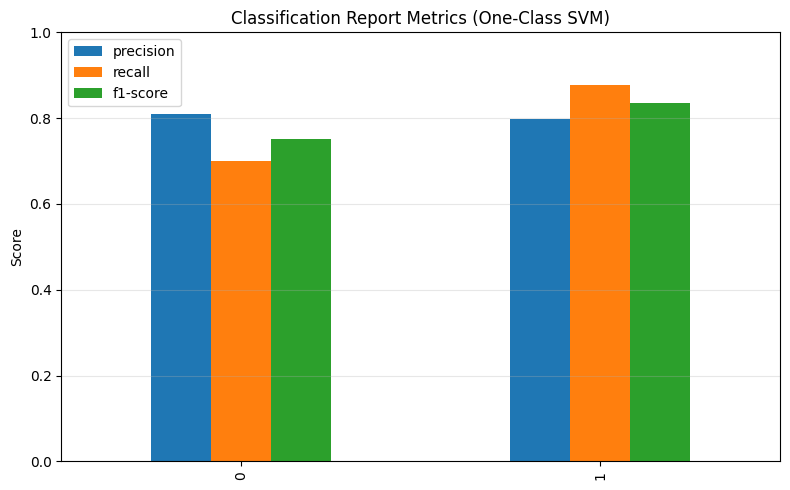

In [24]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

metrics = report_df.loc[['0','1'], ['precision','recall','f1-score']]

fig, ax = plt.subplots(figsize=(8,5))

metrics.plot(kind='bar', ax=ax)

plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Classification Report Metrics (One-Class SVM)")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/ocsvm_classification_report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

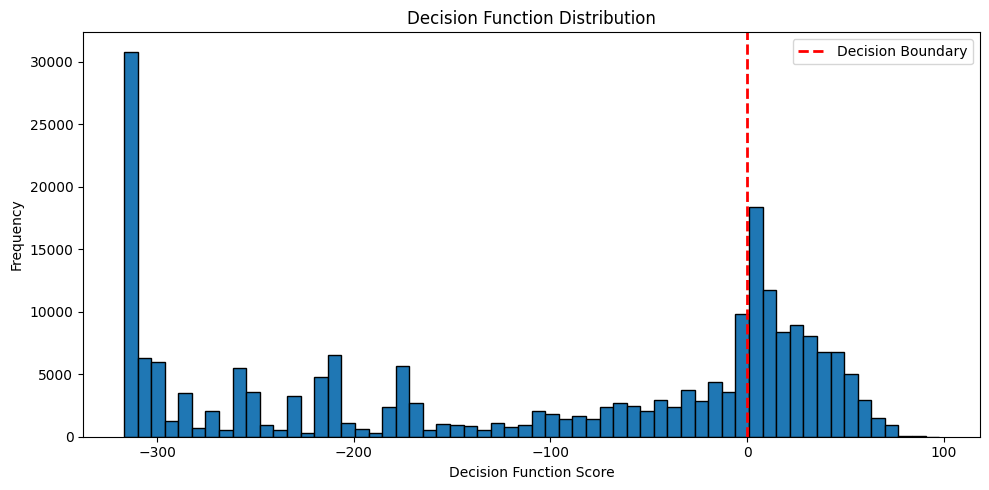

In [25]:
decision_scores = best_ocsvm.decision_function(X_scaled)

plt.figure(figsize=(10,5))

plt.hist(
    decision_scores,
    bins=60,
    edgecolor='black'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label="Decision Boundary"
)

plt.xlabel("Decision Function Score")
plt.ylabel("Frequency")
plt.title("Decision Function Distribution")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/ocsvm_decision_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()